# PA005 - High Value Customer Identification (Insiders)

# SOLUTION PLANNING

"All in one place" is an online retail store that sells second-hand products from various brands at lower prices.

With just over a year of operation, the marketing team noticed that some customers from their base purchase more expensive products more frequently, contributing significantly to the company's revenue.

Based on this insight, the marketing team decided to launch a loyalty program for the top customers in their base, named Insiders. However, the marketing team lacks the necessary knowledge to select the participating customers for this program.

As a result, this task was assigned to the company's data team, where a solution that ultimately provides a list of customers to be invited to participate in the Insiders program should be developed. Additionally, a report answering the following questions should be delivered:

1. Who are the eligible individuals to participate in the program?
    - Revenue:
        - High average ticket value
        - High customer lifetime value (LTV)
        - Low recency
        - Low churn probability
        - High LTV prediction
        - High purchase propensity
        - Cost:

        - Low return rate
        - Purchase Experience:

        - High average ratings  

2. How many customers will be part of the group?
        - Total number of customers
        - % of the insiders group
    
3.  What are the main characteristics of these customers?
    - Customer characteristics:
        - Age
        - Location
       
    - Consumption characteristics:
        - Attributes of clustering

4. What percentage of the revenue comes from the selected group?
    - Total annual revenue
    - Revenue from the Insiders group

5. What is the revenue expectation for this group in the upcoming months?
    - LTV (Customer Lifetime Value) of the Insiders group
    - Cohort analysis
    
6. What are the eligibility criteria for someone to join the group?
    - Define the frequency (1 month, 2 months, etc.).
    - The person needs to be similar to another person in the group.
    - What are the criteria for someone to be removed from the group?

7. Define the frequency (1 month, 2 months, etc.).
    - The person needs to be dissimilar to another person in the group.
    - How can we ensure that the group performs better than the rest of the customer base?

8. A/B testing.
    - Bayesian A/B testing.
    - Hypothesis testing.
    - What actions can the marketing team take to increase revenue?

9. Discounts.
    - Purchase preferences.
    - Company visits.

**SOLUTION PLANNING**

1 - Input:
    Business Problem: Hight value customers identification and selection in order to join a loyalty program.
    Dataset: sales datas from an e-commerce, collected trough an one year period.

2 - Output:
    List containing the customer identification and if they are eligible or not to the loyalty program.
    Report, answering the business questions and explaining how the selection was made.
    
3 - Tasks
    - Who are the eligible individuals to participate in the program?
        Understanding of what elegible means and what are the most valuable customer.
        
        
    - How many customers will be part of the group?
        
        
    - What are the main characteristics of these customers?
        
    
    - What percentage of the revenue comes from the selected group?
        
    
    - What is the revenue expectation for this group in the upcoming months?
        
    
    - What are the conditions for someone to be eligible for the group?
        
    
    - What are the conditions for someone to be removed from the group?
        
    
    - What assurance is there that the group is better than the rest of the base?
        
    
    - What actions can the marketing team take to increase revenue?
        


# 0 - IMPORTS </font>

In [1]:
# Data Maniputalion and Data Analysis
import re
import warnings

import pandas                as pd
import seaborn               as sns
import numpy                 as np

from ydata_profiling         import ProfileReport
from matplotlib              import pyplot          as plt

# ML Algorithms
import umap.umap_            as umap

from sklearn.manifold        import TSNE
from sklearn                 import mixture as mx
from sklearn                 import preprocessing as pp
from sklearn                 import ensemble      as en
from sklearn                 import decomposition as dd
from sklearn                 import cluster       as cc
from sklearn                 import metrics       as mt
from sklearn                 import ensemble      as en
from yellowbrick.cluster     import KElbowVisualizer, SilhouetteVisualizer

# Loading Images and display settings
from IPython.display         import Image, display
from IPython.core.display    import HTML

warnings.filterwarnings( 'ignore' )

## 0.1 - Helper Functions

In [2]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline
    
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25,12]
    plt.rcParams['font.size'] = 24
    
    display( HTML( '<style>.container {width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    
    sns.set()
jupyter_settings()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# 1 - DATA LOADING

## 1.1 - LOADING DATA

In [3]:
df = pd.read_csv("../data/raw/Ecommerce.csv")

# drop extra column
df = df.drop( columns=['Unnamed: 8'], axis=1)

## 1.2 - DATA DESCRIPTIVE

### 1.2.1 - RENAME COLUMNS

In [4]:
df1 = df.copy()

In [5]:
cols_new = ['invoice_no','stock_code','description','quantity','invoice_date','unit_price','customer_id','country']
df1.columns = cols_new

### 1.2.2 - DATA DIMENSIONS

In [ ]:
#print('Number of columns: {}'.format( df1.shape[1] ) )
#print('Number of rows: {}'.format( df1.shape[0] ) )

### 1.2.3 - DATA TYPES

In [ ]:
#df1.dtypes

### 1.2.4 - CHECK NA VALUES

In [ ]:
#df1.isna().sum()

### 1.2.5 - REPLACE NAN VALUES

In [6]:
# The datas containing missing customer_id are being moved to a new dataset
df_missing = df1.loc[df1['customer_id'].isna(), :]
df_not_missing = df1.loc[~df1['customer_id'].isna(),:]

In [7]:
# Identifying which are the invoices without customer id
missing_invoice = df_missing['invoice_no'].drop_duplicates().tolist()

In [8]:
# Create reference and creating a customer_id for the invoices.
df_backup = pd.DataFrame( df_missing['invoice_no'].drop_duplicates() ) # creating a copy from the dataset that contains missing invoice_no
df_backup['customer_id'] = np.arange( 19000, 19000+len( df_backup), 1) # creating a invoice_no for the datas without this information

# Merge orginal with reference dataframe
df1 = pd.merge( df1, df_backup, on='invoice_no', how='left')

# Coalese
df1['customer_id'] = df1['customer_id_x'].combine_first( df1['customer_id_y'] ) # combine the dataset from the "main" column that contains the original values with the new column that contains the created value for invoice_no 

# Drop extra columns
df1 = df1.drop( columns=['customer_id_x','customer_id_y'], axis=1 )

### 1.2.6 - CHANGE DTYPES

In [ ]:
#df1.dtypes

In [9]:
df1[ 'invoice_date'] = pd.to_datetime( df1['invoice_date'], format='%d-%b-%y') # changing the data on the column invoice data to match the correct data type

df1['customer_id'] = df1['customer_id'].astype( int ) # changing the data on the column customer id data to match the correct data type

### 1.2.7 - DESCRIPTIVE STATISTICS

In [ ]:
#num_attributes = df1.select_dtypes( include=['int64', 'float64'] ) # add numerical datas into a new data frame
#cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'] ) # add categorical datas into a new data frame

### 1.2.7.1 - Numerical Attributes

In [ ]:
# Central Tendency
#ct1 = pd.DataFrame( num_attributes.apply( np.mean ) ).T
#ct2 = pd.DataFrame( num_attributes.apply( np.median ) ).T

# Dispersion - 
#d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T
#d2 = pd.DataFrame( num_attributes.apply( np.min ) ).T
#d3 = pd.DataFrame( num_attributes.apply( np.max ) ).T
#d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max() - x.min() ) ).T
#d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T
#d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T

# Concatenate
#m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
#m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
#m

### 1.2.7.2 - Categorical Attributes

##### Invoice No

In [ ]:
# # Problem: There are letters and numbers on the invoice_no column
# df_letter_invoice = df1.loc[df1['invoice_no'].apply( lambda x: bool( re.search('[^0-9]+', x) ) ), :]
# df_letter_invoice.head()

# print('Total of invoices: {}'.format( len( df_letter_invoice ) ) )
# print('Total of invoices with negative qty: {}'.format( len(df_letter_invoice[ df_letter_invoice['quantity']<0 ] ) ) )

In [ ]:
# SOLUTION: Understand if every invoice_no that contains letter are negative and decide if these will be removed, separated, etc.

# How to find out if every invoice_no that starts with "C" has a negative quantity

# Total of invoice_no that contais letters
#aux1 = df1.loc[df1['invoice_no'].apply( lambda x: bool( re.search('[^0-9]+', x) ) ), :]
#len(aux1)

# Qty of invoices_no that the qty is negative
#len( aux1[aux1['quantity']<0])

##### Stock Code

In [ ]:
# # Problem: There are codes on stock_code that are composed of letters and we do not know the meaning
# df1.loc[df1['stock_code'].apply( lambda x: bool( re.search('^[a-zA-Z]+$', x ) ) ), 'stock_code'].unique()

# # SOLUTION: Remove sotck_code composed of letters or codes as per ['POST', 'D', 'M', 'PADS', 'DOT', 'CRUK']

##### Description

In [ ]:
# ACTION: REMOVE THIS COLUMN FROM THE DATASET AS THIS DO NOT HELPS TO GENERATE A CLUSTER
# df1.head()

##### Country

In [ ]:
# df1['country'].unique()

In [ ]:
# # Qty sales made per country
# df1['country'].value_counts( normalize=True )

# 2 - DATA FILTERING

On this project, the step **DATA FILTERING** will be done earlier as some features are been calculated from the dataset and are combined with that dataset later on, and it's our duty to make sure that we are keeping our data clean and without errors.

In [11]:
df2 = df1.copy()

In [12]:
# --- NUMERICAL ATTRIBUTES ---
df2 = df2.loc[df2['unit_price'] >= 0.04, :]

# --- CATEGORICAL ATTRIBUTES ---
df2 = df2[~df2['stock_code'].isin( ['POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY', 'DCGSSGIRL', 'PADS', 'B', 'CRUK'] ) ]

# Description
df2 = df2.drop( columns='description', axis=1)

# MAP
df2 = df2[~df2['country']. isin( ['European Community','Unspecified'] ) ]

# Bad Users
df2 = df2[~df2['customer_id'].isin( [16446] ) ]

# Quantity
df2_returns = df2.loc[df1['quantity'] < 0, :]   # Dataset containing only returns
df2_purchases = df2.loc[df1['quantity'] >=0, :] # Dataset containing only sells

# 3 - FATURE ENGINEERING

In [13]:
df3 = df2.copy()

In [14]:
# Features
# Moving Average
# Qty of purchases by month, before 26th and after 26th

In [15]:
# data reference
df_ref = df2.drop( ['invoice_no','stock_code','quantity','invoice_date','unit_price','country'],axis=1).drop_duplicates(ignore_index=True)

## 3.1 - Gross Revenue

In [16]:
# Gross Revenue
df2_purchases.loc[:, 'gross_revenue'] = df2_purchases.loc[:, 'quantity'] * df2_purchases.loc[:, 'unit_price']

# Monetary
df_monetary = df2_purchases.loc[:, ['customer_id', 'gross_revenue']].groupby('customer_id').sum().reset_index()
df_ref = pd.merge( df_ref, df_monetary, on='customer_id', how='left')

df_ref.isna().sum()

customer_id       0
gross_revenue    91
dtype: int64

## 3.2 - Recency - Day from last purchase

In [17]:
# Recency
df_recency = df2_purchases.loc[:, ['customer_id', 'invoice_date']].groupby('customer_id').max().reset_index()
df_recency['recency_days'] = (df2_purchases['invoice_date'].max() - df_recency['invoice_date']).dt.days
df_recency = df_recency[['customer_id','recency_days']].copy()
df_ref = pd.merge( df_ref, df_recency, on='customer_id', how='left')

df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
dtype: int64

## 3.3 - Qty of purchases

In [ ]:
# df_freq = (df2_purchases.loc[:, ['customer_id', 'invoice_no']].drop_duplicates()
#                                                              .groupby('customer_id')
#                                                              .count()
#                                                              .reset_index()
#                                                              .rename( columns={'invoice_no':'qty_invoices'}) )
                
# df_ref = pd.merge(df_ref, df_freq, on='customer_id', how='left')

# df_ref.isna().sum()

## 3.4 Qty of products purchased

In [18]:
# Number of products
df_freqp = ( df2_purchases.loc[:,['customer_id', 'quantity']].groupby('customer_id')
                                                           .sum().reset_index()
                                                           .rename( columns={'quantity':'qty_of_products'}) )

df_ref = pd.merge(df_ref, df_freqp, on='customer_id', how='left')
df_ref.isna().sum()

customer_id         0
gross_revenue      91
recency_days       91
qty_of_products    91
dtype: int64

## 3.5 - Range of Products per Customer

In [ ]:
# df_prod = ( df2_purchases.loc[:,['customer_id', 'stock_code']].groupby('customer_id')
#                                                             .count()
#                                                             .reset_index()
#                                                             .rename( columns={'stock_code':'range_of_products'}) )
            
# df_ref = pd.merge(df_ref, df_prod, on='customer_id', how='left')
# df_ref.isna().sum()

## 3.6 - Average Ticket Value

In [ ]:
# # Avg Ticket
# df_avg_ticket = ( df2_purchases.loc[:, ['customer_id','gross_revenue']].groupby('customer_id')
#                                                                        .mean()
#                                                                        .reset_index()
#                                                                        .rename( columns={'gross_revenue':'avg_ticket'}) )

# df_ref = pd.merge( df_ref, df_avg_ticket, on='customer_id', how='left')
# df_ref.isna().sum()

## 3.7 - Average Recency Days

In [ ]:
# df_aux = ( df2_purchases[['customer_id','invoice_date']].drop_duplicates()
#                                                       .sort_values( ['customer_id', 'invoice_date'], ascending=[False, False] ) ) 
    
# df_aux['next_customer_id'] = df_aux['customer_id'].shift() # next customer
# df_aux['previous_date'] = df_aux['invoice_date'].shift() # next invoice date
# df_aux['avg_recency_days'] = df_aux.apply( lambda x: x['invoice_date'] - x['previous_date'] if x['customer_id'] == x['next_customer_id'] else np.nan, axis=1 ).dt.days

# df_recency = df_recency[['customer_id','recency_days']].copy() # calculating the recency day

# df_aux = df_aux.drop(['invoice_date','next_customer_id','previous_date'], axis=1).dropna()# leaving only the interested variable and the customer_id into the aux dataframe

# # calculating the average for customer
# df_avg_recency_days = df_aux.groupby('customer_id').mean().reset_index()

# # meging the result with the original df

# df_ref= pd.merge(df_ref, df_avg_recency_days, on='customer_id', how='left')

# df_ref.isna().sum()

## 3.8 - Frequency of Purchases

In [19]:
df2_max = df2_purchases[['customer_id','invoice_date']].drop_duplicates().groupby('customer_id').max().reset_index() # finding the last date of purchase per customer
df2_min = df2_purchases[['customer_id','invoice_date']].drop_duplicates().groupby('customer_id').min().reset_index() # finding the last date of purchase per customer

df_aux = ( df2_purchases[['customer_id','invoice_no','invoice_date']].drop_duplicates()
                                                           .groupby('customer_id')
                                                           .agg( max_ =('invoice_date', 'max'),
                                                                 min_ =('invoice_date', 'min'),
                                                                 days_=('invoice_date', lambda x:( (x.max() - x.min() ).days)+1),
                                                                 buy_ =('invoice_no', 'count'))).reset_index()

# Frequency
df_aux['frequency'] = df_aux[['buy_', 'days_']].apply( lambda x: x['buy_'] / x['days_'] if x['days_'] != 0 else 0, axis=1 )

# Merge
df_ref = pd.merge(df_ref, df_aux[['customer_id','frequency']], on='customer_id', how='left')

df_ref.isna().sum()

customer_id         0
gross_revenue      91
recency_days       91
qty_of_products    91
frequency          91
dtype: int64

## 3.9 - Returns

In [20]:
# Number of returns
df_returns = df2_returns[['customer_id','quantity']].groupby('customer_id').sum().reset_index().rename( columns={'quantity':'qty_returns'})
df_returns['qty_returns'] = df_returns['qty_returns'] * -1

df_ref = pd.merge( df_ref, df_returns, on='customer_id', how='left')
df_ref.loc[df_ref['qty_returns'].isna(), 'qty_returns'] = 0

df_ref.isna().sum()

customer_id         0
gross_revenue      91
recency_days       91
qty_of_products    91
frequency          91
qty_returns         0
dtype: int64

## 3.10 - Qty avg of producst per customer

In [ ]:
# df_aux = ( df2_purchases.loc[:, ['customer_id','invoice_no','quantity']].groupby('customer_id')
#                                                                           .agg( n_purchase=('invoice_no', 'nunique'),
#                                                                                 n_products=('quantity', 'sum') )
#                                                                           .reset_index() )
# # AVG
# df_aux['avg_basket_size'] = df_aux['n_products'] / df_aux['n_purchase']

# # Merge
# df_ref = pd.merge( df_ref, df_aux, on='customer_id', how='left')
# df_ref.isna().sum()

# <font color='black'> 4 - EDA </font>

In [21]:
df4 = df_ref.dropna()
df4.isna().sum()

customer_id        0
gross_revenue      0
recency_days       0
qty_of_products    0
frequency          0
qty_returns        0
dtype: int64

## 4.1 - Univariate Analysis

Metrics to be checked out:

1. Cluster coesos - separados
2. Metrics:
    - Min, Max, Range (dispersion)
    - Mean and Median
    - Standard Deviation and Variance
    - CV (Coefficient of Variation)
    - Distribuition

In [ ]:
#prof = ProfileReport(df4)
#prof.to_file('data_descriptive.html') 

## 4.2 - Bivariate Analysis

In [22]:
cols = ['customer_id']
df42 = df4.drop( cols, axis=1 )

In [ ]:
plt.figure( figsize=(12, 15) )
sns.pairplot( df4 )

## 4.3 - Space of Study

In [23]:
# Original Dataset
#df43 = df4.drop( columns=['customer_id'], axis=1 ).copy()

# Selected Dataset
cols_selected = ['customer_id', 'gross_revenue', 'recency_days', 'qty_of_products', 'frequency' , 'qty_returns']
df43 = df4[ cols_selected ]

In [24]:
# Standardization
mms = pp.MinMaxScaler()

# Transformer
df43['gross_revenue']     = mms.fit_transform( df43[['gross_revenue']])
df43['recency_days']      = mms.fit_transform( df43[['recency_days']])
#df43['qty_invoices']      = mms.fit_transform( df43[['qty_invoices']])
df43['qty_of_products']   = mms.fit_transform( df43[['qty_of_products']])
#df43['range_of_products'] = mms.fit_transform( df43[['range_of_products']])
#df43['avg_ticket']        = mms.fit_transform( df43[['avg_ticket']])
#df43['avg_recency_days']  = mms.fit_transform( df43[['avg_recency_days']])
df43['frequency']         = mms.fit_transform( df43[['frequency']])
df43['qty_returns']       = mms.fit_transform( df43[['qty_returns']])
#df43['n_purchase']        = mms.fit_transform( df43[['n_purchase']])
#df43['n_products']        = mms.fit_transform( df43[['n_products']])
#df43['avg_basket_size']   = mms.fit_transform( df43[['avg_basket_size']])

X = df43.copy()

In [25]:
X.shape

(5695, 6)

### 4.3.1 - PCA

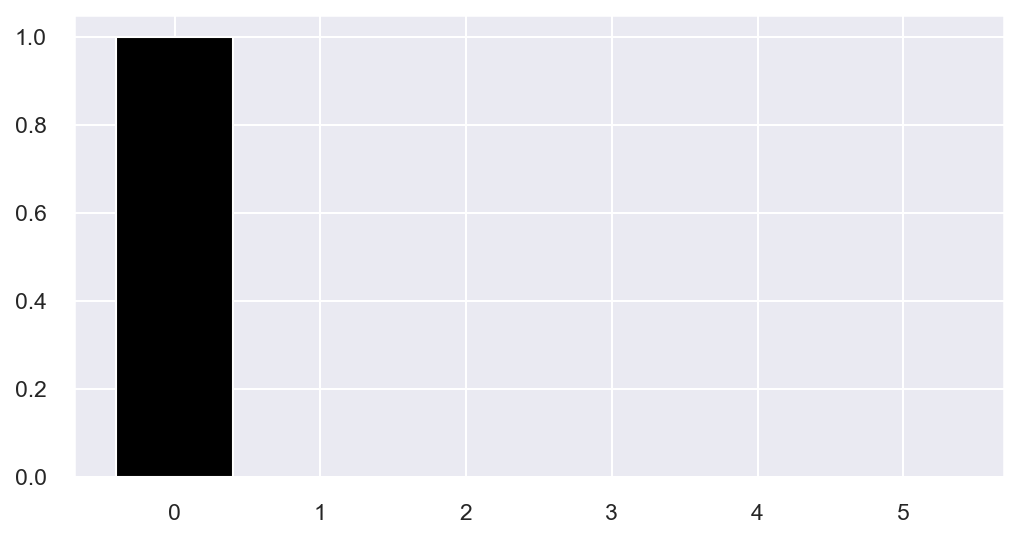

In [26]:
fig, axs = plt.subplots(figsize = (8, 4), dpi=150)
pca = dd.PCA ( n_components = X.shape[1] )

principal_components = pca.fit_transform( X )

# plot explained variables
features = range( pca.n_components_ )

plt.bar( features, pca.explained_variance_ratio_, color='black' )

# pca component

df_pca = pd.DataFrame( principal_components )

<AxesSubplot:xlabel='0', ylabel='1'>

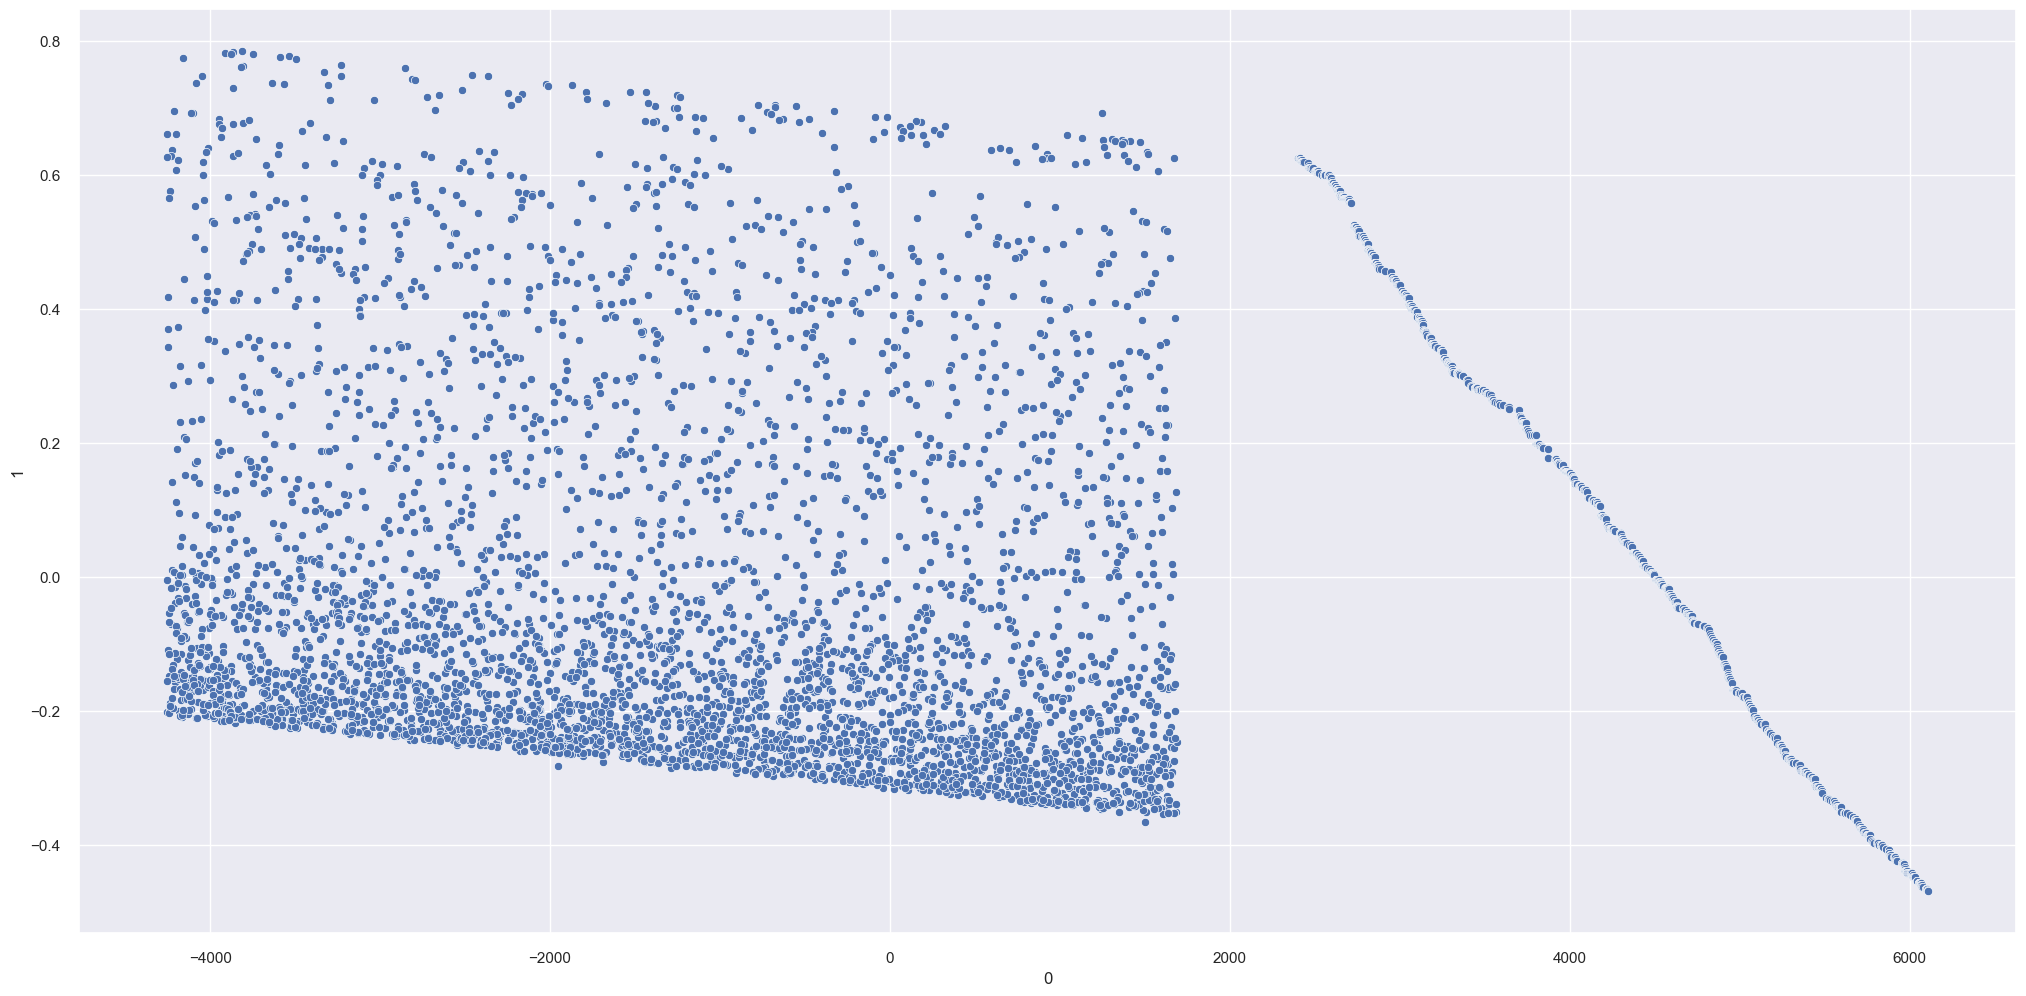

In [27]:
sns.scatterplot( x=0, y=1, data=df_pca)

### 4.3.2 - UMAP

<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

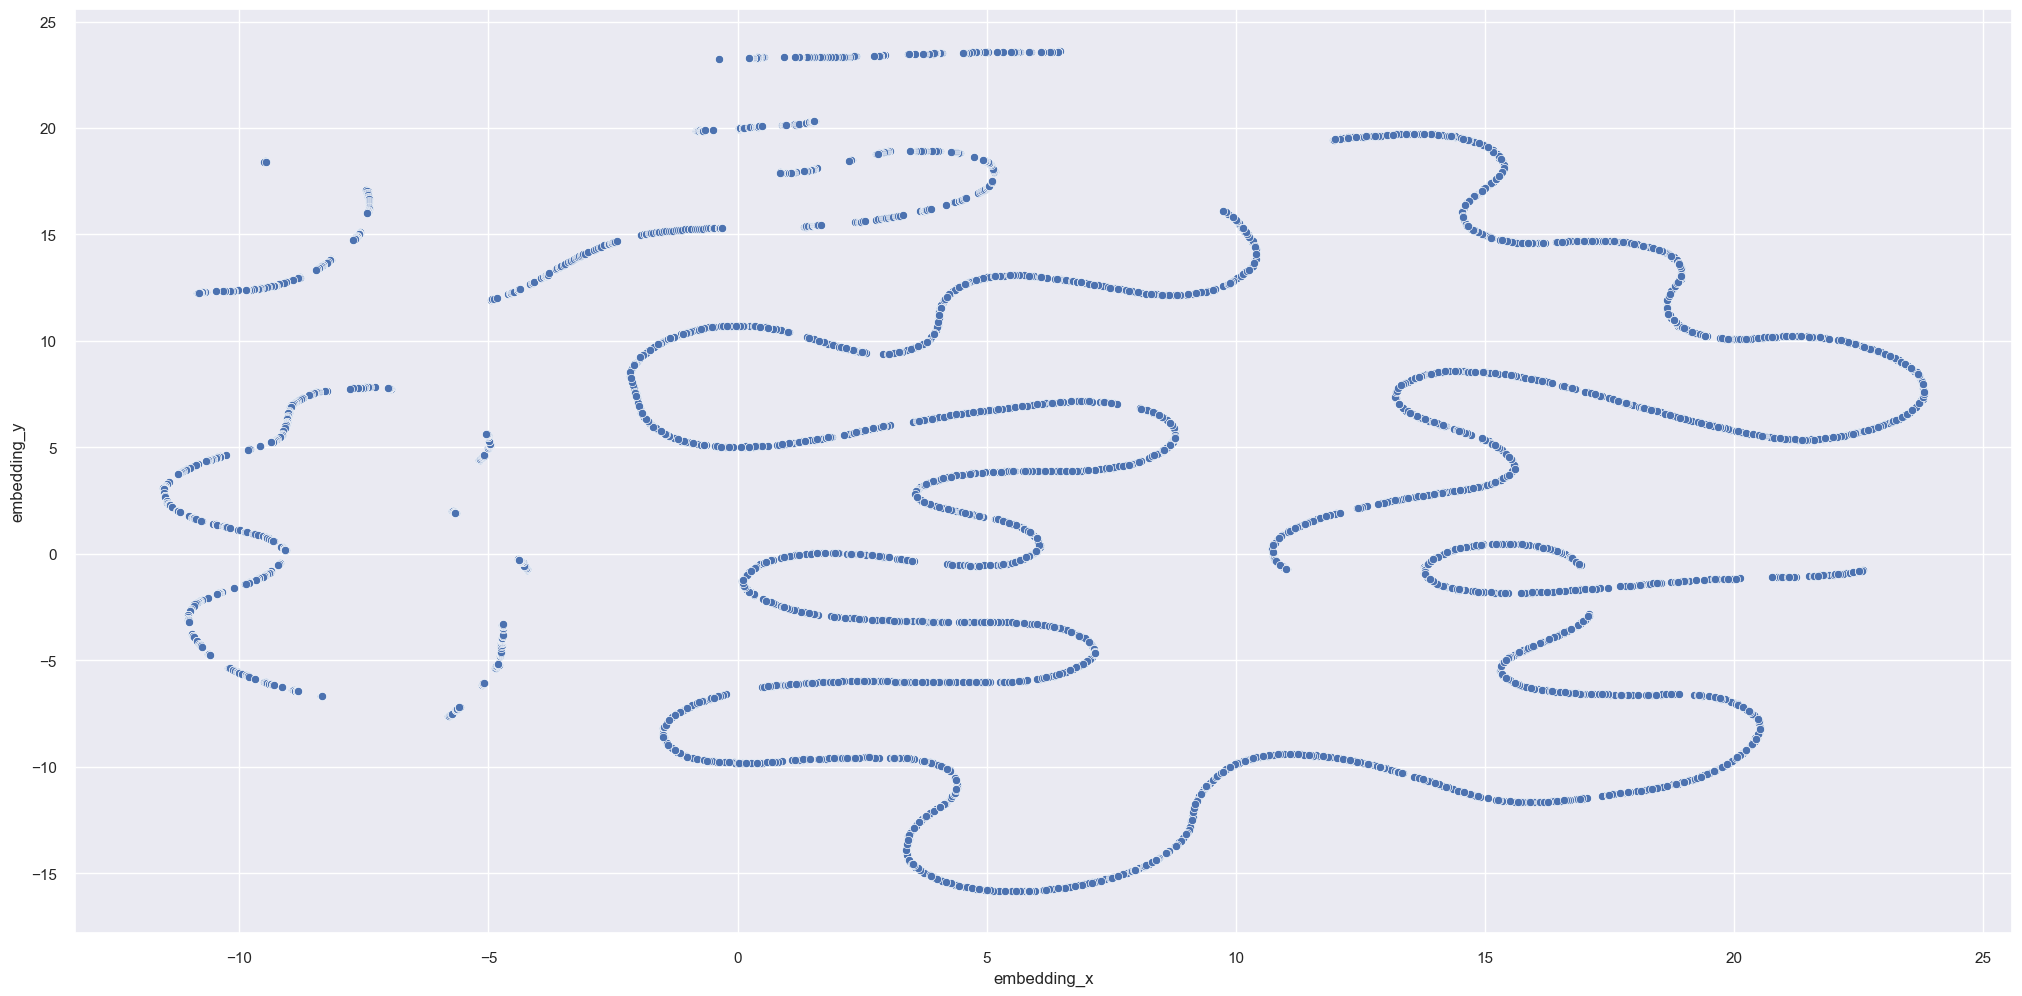

In [28]:
# UMAP 
reducer = umap.UMAP( random_state=42 )
embedding = reducer.fit_transform( X )

# Embedding 
df_pca['embedding_x'] = embedding[:, 0]
df_pca['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_pca)
                                

### 4.3.3 - TSNE

<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

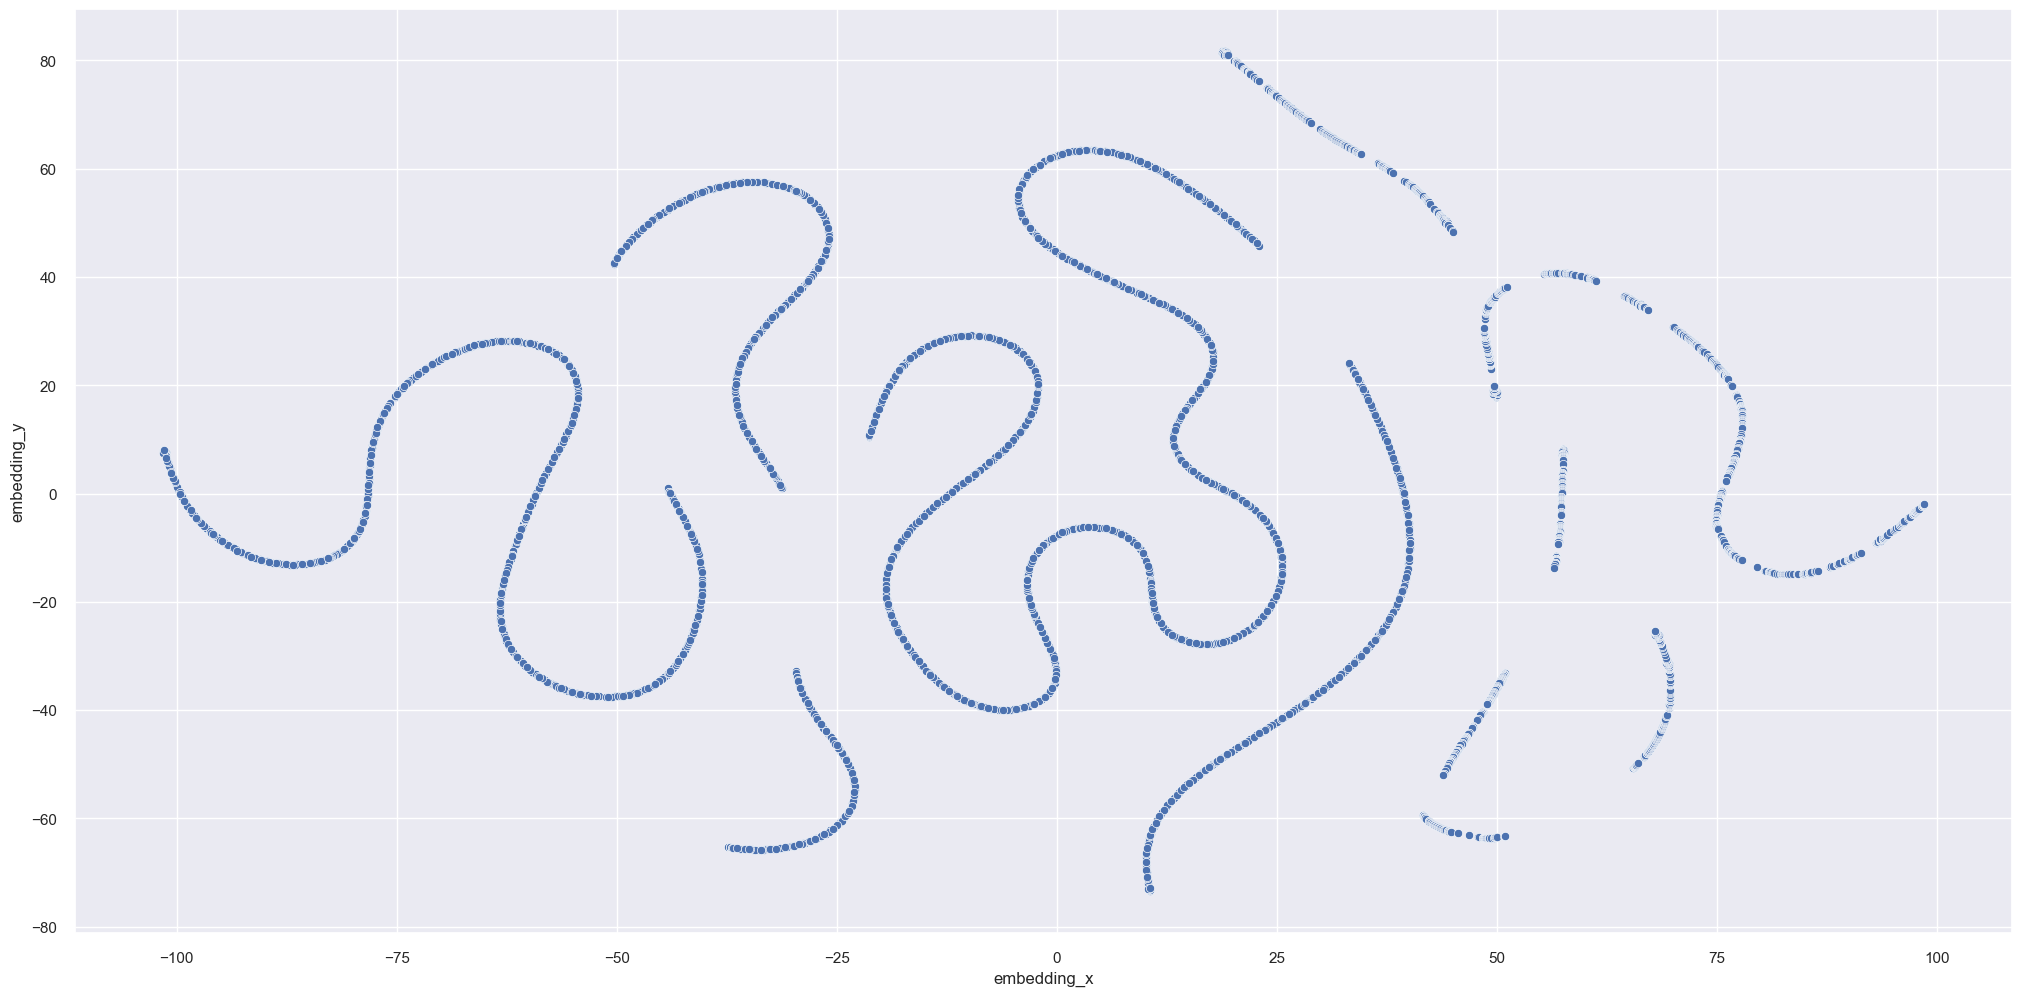

In [29]:
# UMAP 
reducer = TSNE( n_components=2, n_jobs=-1, random_state=42 )
embedding = reducer.fit_transform( X )

# Embedding 
df_pca['embedding_x'] = embedding[:, 0]
df_pca['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_pca)
                                

### 4.3.4 - Tree-Based Embedding

In [30]:
# Training dataset
X = df43.drop( columns=['customer_id','gross_revenue'], axis=1 ).copy()
y = df43['gross_revenue']

# model definition
rf_model = en.RandomForestRegressor( n_estimators=100, random_state=42 )

# model trainig
rf_model.fit(X, y)

RandomForestRegressor(random_state=42)

In [31]:
df_leaf = pd.DataFrame( rf_model.apply( X ) ) # here i am selecting the datas from the leaf of tree

<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

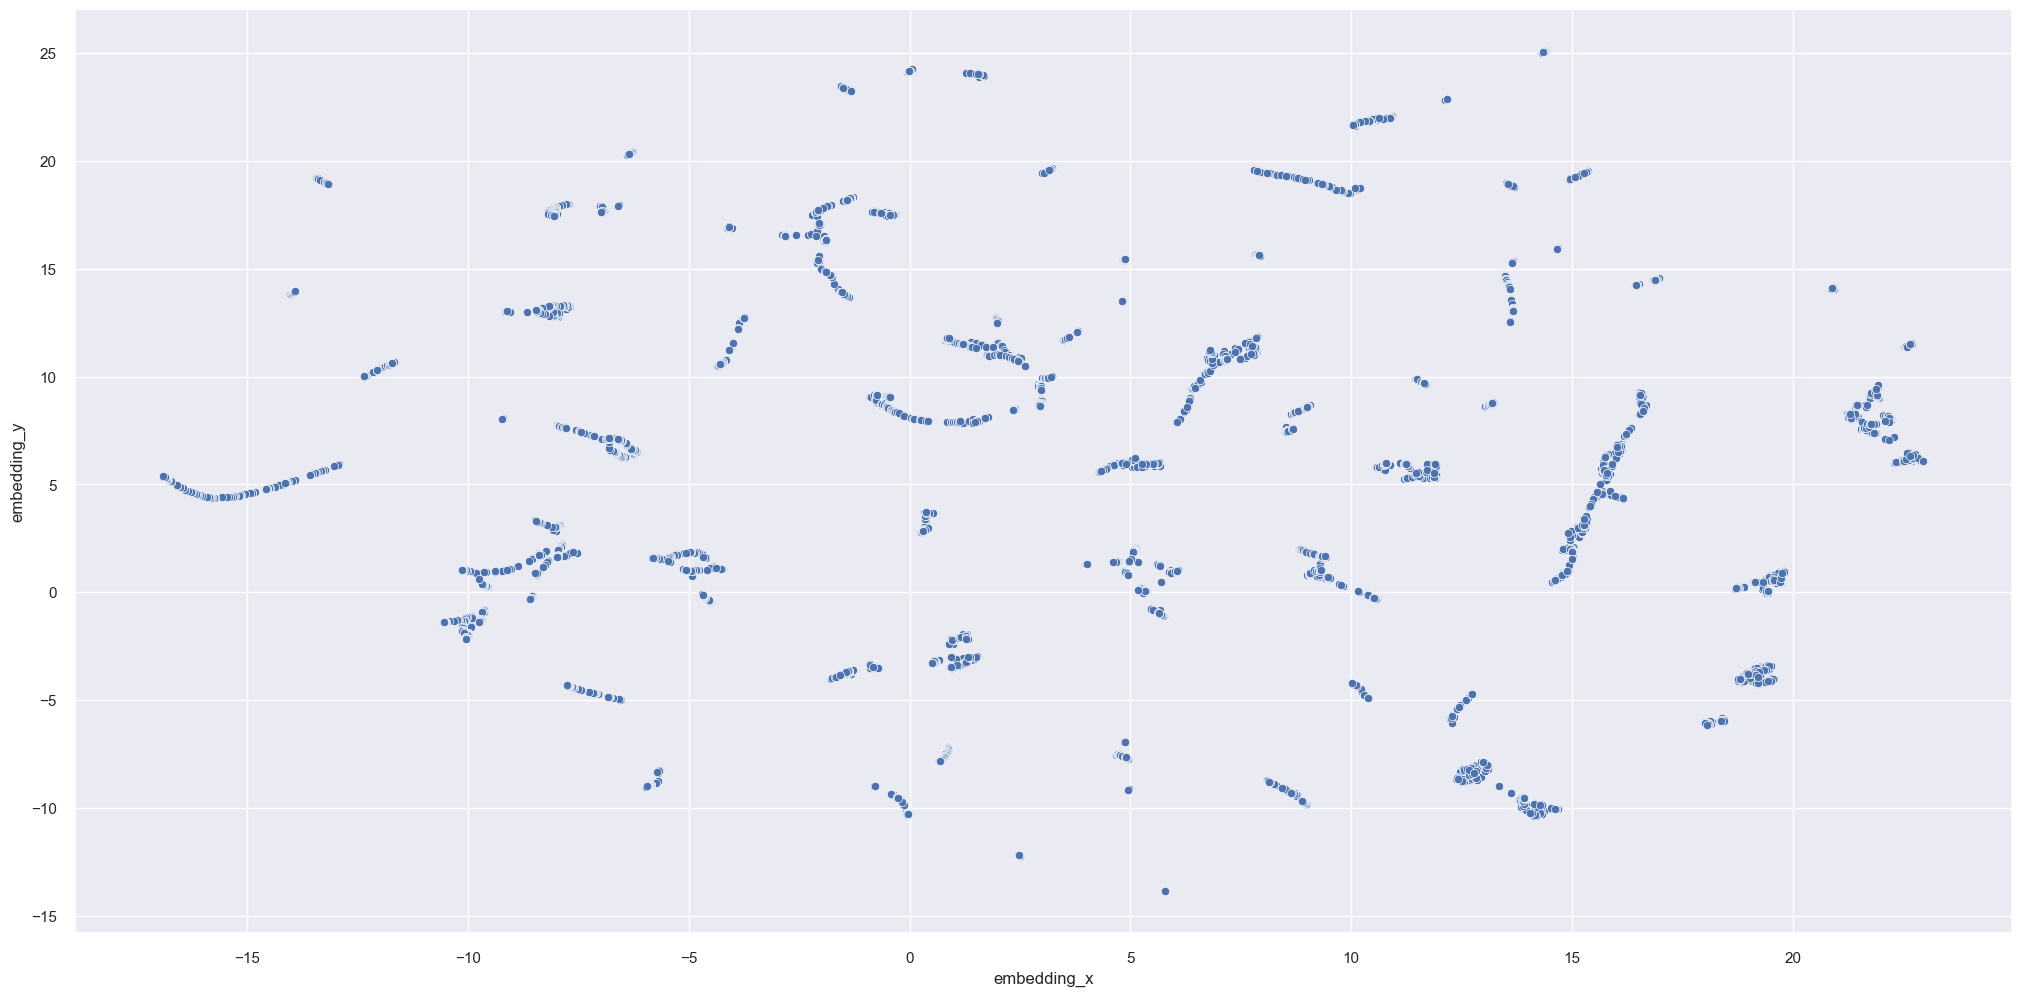

In [32]:
# UMAP 
reducer = umap.UMAP( random_state = 42 )
embedding = reducer.fit_transform( df_leaf )

# Embedding 
df_tree = pd.DataFrame()
df_tree['embedding_x'] = embedding[:, 0]
df_tree['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_tree)

# 5 - DATA PREPARATION

In [33]:
#df5 = df4.copy()
df5 = df_tree.copy()

In [34]:
df5.head()

,embedding_x,embedding_y
0,12.726829,-4.719460
1,13.805153,-9.658109
2,16.288080,7.500883
3,1.097511,-3.423558
4,-4.029222,16.895412


#### Standardization

In [ ]:
#mm = pp.MinMaxScaler()
#ss = pp.StandardScaler()
#rs = pp.RobustScaler()

#df5['gross_revenue']     = mm.fit_transform( df5[['gross_revenue']])

#df5['recency_days']      = mm.fit_transform( df5[['recency_days']])

#df5['qty_invoices']      = mm.fit_transform( df5[['qty_invoices']])

#df5['qty_of_products']   = mm.fit_transform( df5[['qty_of_products']])

#df5['range_of_products'] = mm.fit_transform( df5[['range_of_products']])

#df5['avg_ticket']        = mm.fit_transform( df5[['avg_ticket']])

#df5['avg_recency_days']  = mm.fit_transform( df5[['avg_recency_days']])

#df5['frequency']         = mm.fit_transform( df5[['frequency']])

#df5['qty_returns']       = mm.fit_transform( df5[['qty_returns']])

#df5['n_purchase']        = mm.fit_transform( df5[['n_purchase']])

#df5['n_products']        = mm.fit_transform( df5[['n_products']])

#df5['avg_basket_size']   = mm.fit_transform( df5[['avg_basket_size']])

#variable = 'qty_of_products'

In [ ]:
# Dados AS IS
#print('Min:{} - Max:{}'.format( df5_aux[variable].min(), df5_aux[variable].max() ) )
#sns.displot( df5_aux[variable]);

In [ ]:
# Dados Normalizados e Reescalados
#print('Min:{} - Max:{}'.format( df5[variable].min(), df5[variable].max() ) )
#sns.displot( df5[variable]);

In [ ]:
# BoxPlot
#sns.boxplot(df5_aux[variable]);

# 6 - FEATURE SELECTION

In [35]:
cols_selected = ['customer_id', 'gross_revenue', 'recency_days', 'qty_of_products', 'frequency' , 'qty_returns']

In [ ]:
#df6 = df5[cols_selected].copy()

In [36]:
df6 = df_tree.copy()

# 7 - FINE TUNING

In [37]:
X = df_tree.copy()

In [38]:
cluster = np.arange(2, 19, 1)

In [39]:
X.head()

,embedding_x,embedding_y
0,12.726829,-4.719460
1,13.805153,-9.658109
2,16.288080,7.500883
3,1.097511,-3.423558
4,-4.029222,16.895412


## 7.1 - K-Means

In [40]:
kmeans_list = []
for k in cluster:
    # Model Definition
    kmeans_model = cc.KMeans( n_clusters=k )

    # Model Training
    kmeans_model.fit( X )
    # Model Predict
    labels = kmeans_model.predict( X )

    # Model Performance
    sil = mt.silhouette_score( X, labels, metric='euclidean')
    kmeans_list.append( sil )

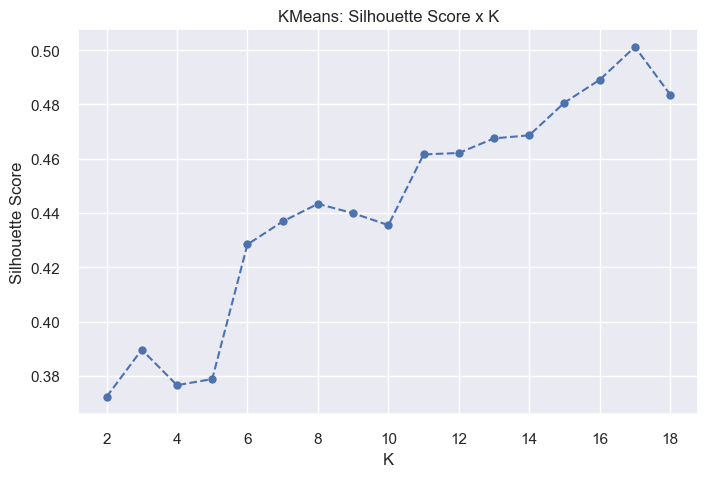

In [41]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, kmeans_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('KMeans: Silhouette Score x K');

## 7.2 - Gaussiann Mixture Model

AIC - Ajuste dos dados
BIC - Ajuste dos parametros

In [43]:
gmm_list = [] 
for k in cluster:
    # Model Definition
    gmm_model = mx.GaussianMixture( n_components=k )
    
    # Model Training
    gmm_model.fit( X )

    # Model Predict
    labels = gmm_model.predict( X )

    # Model Performance
    gmm_sil = mt.silhouette_score( X, labels, metric='euclidean')
    gmm_list.append( gmm_sil )

Text(0.5, 1.0, 'GMM: Silhouette Score x K')

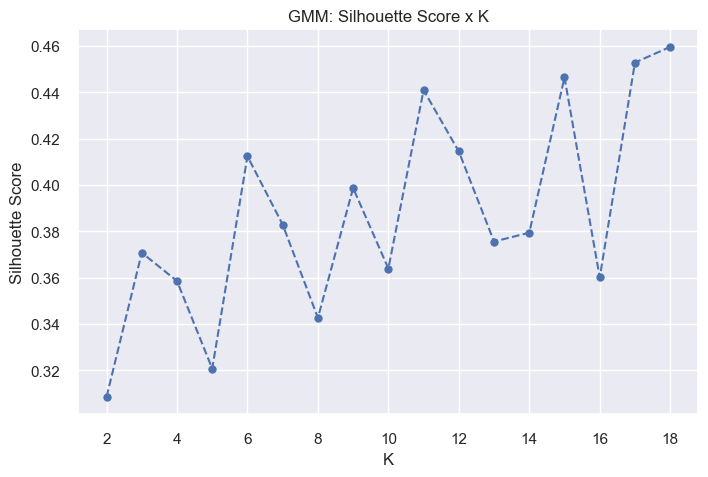

In [44]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, gmm_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('GMM: Silhouette Score x K')

## 7.3 - Hierarchical Clustering

In [45]:
from scipy.cluster import hierarchy as hc

In [46]:
# Model Definition and Training
hc_model = hc.linkage( X, 'ward')

[]

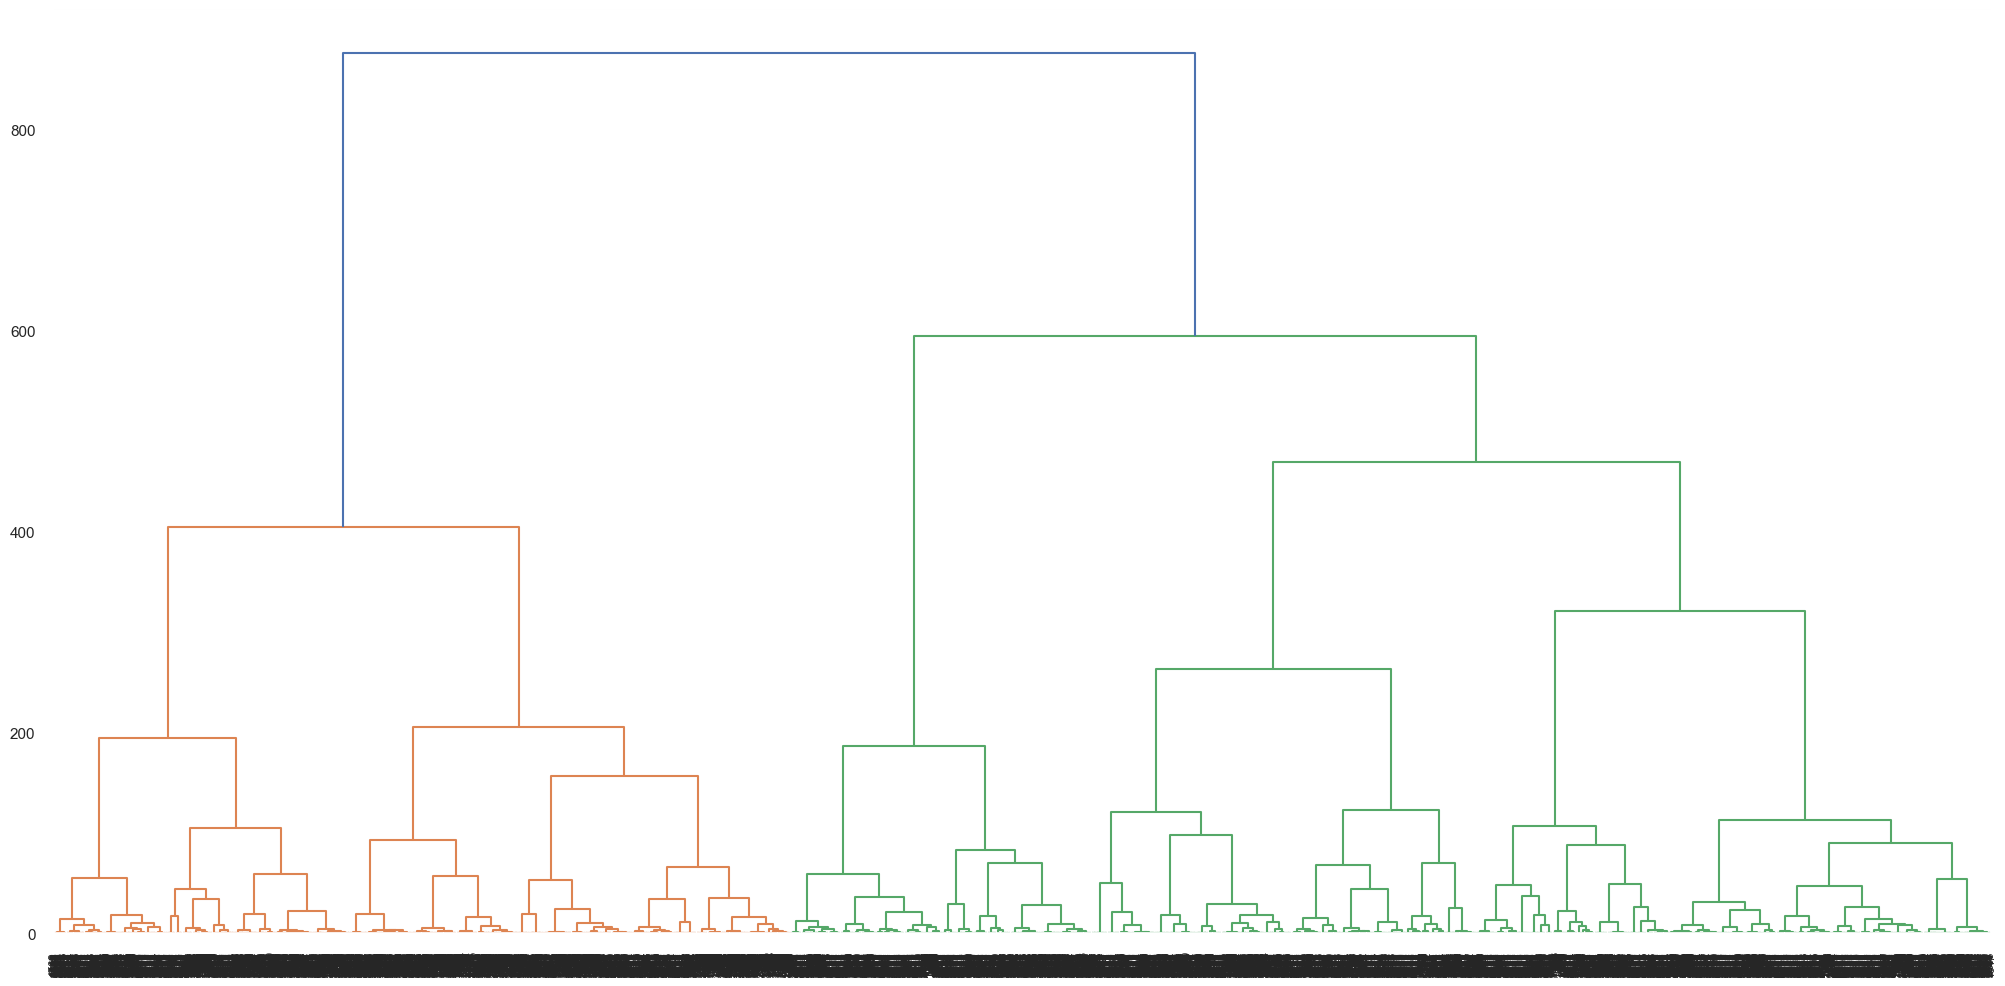

In [47]:
hc.dendrogram(
              hc_model,
              leaf_rotation=90,
              leaf_font_size=8
)

plt.plot()

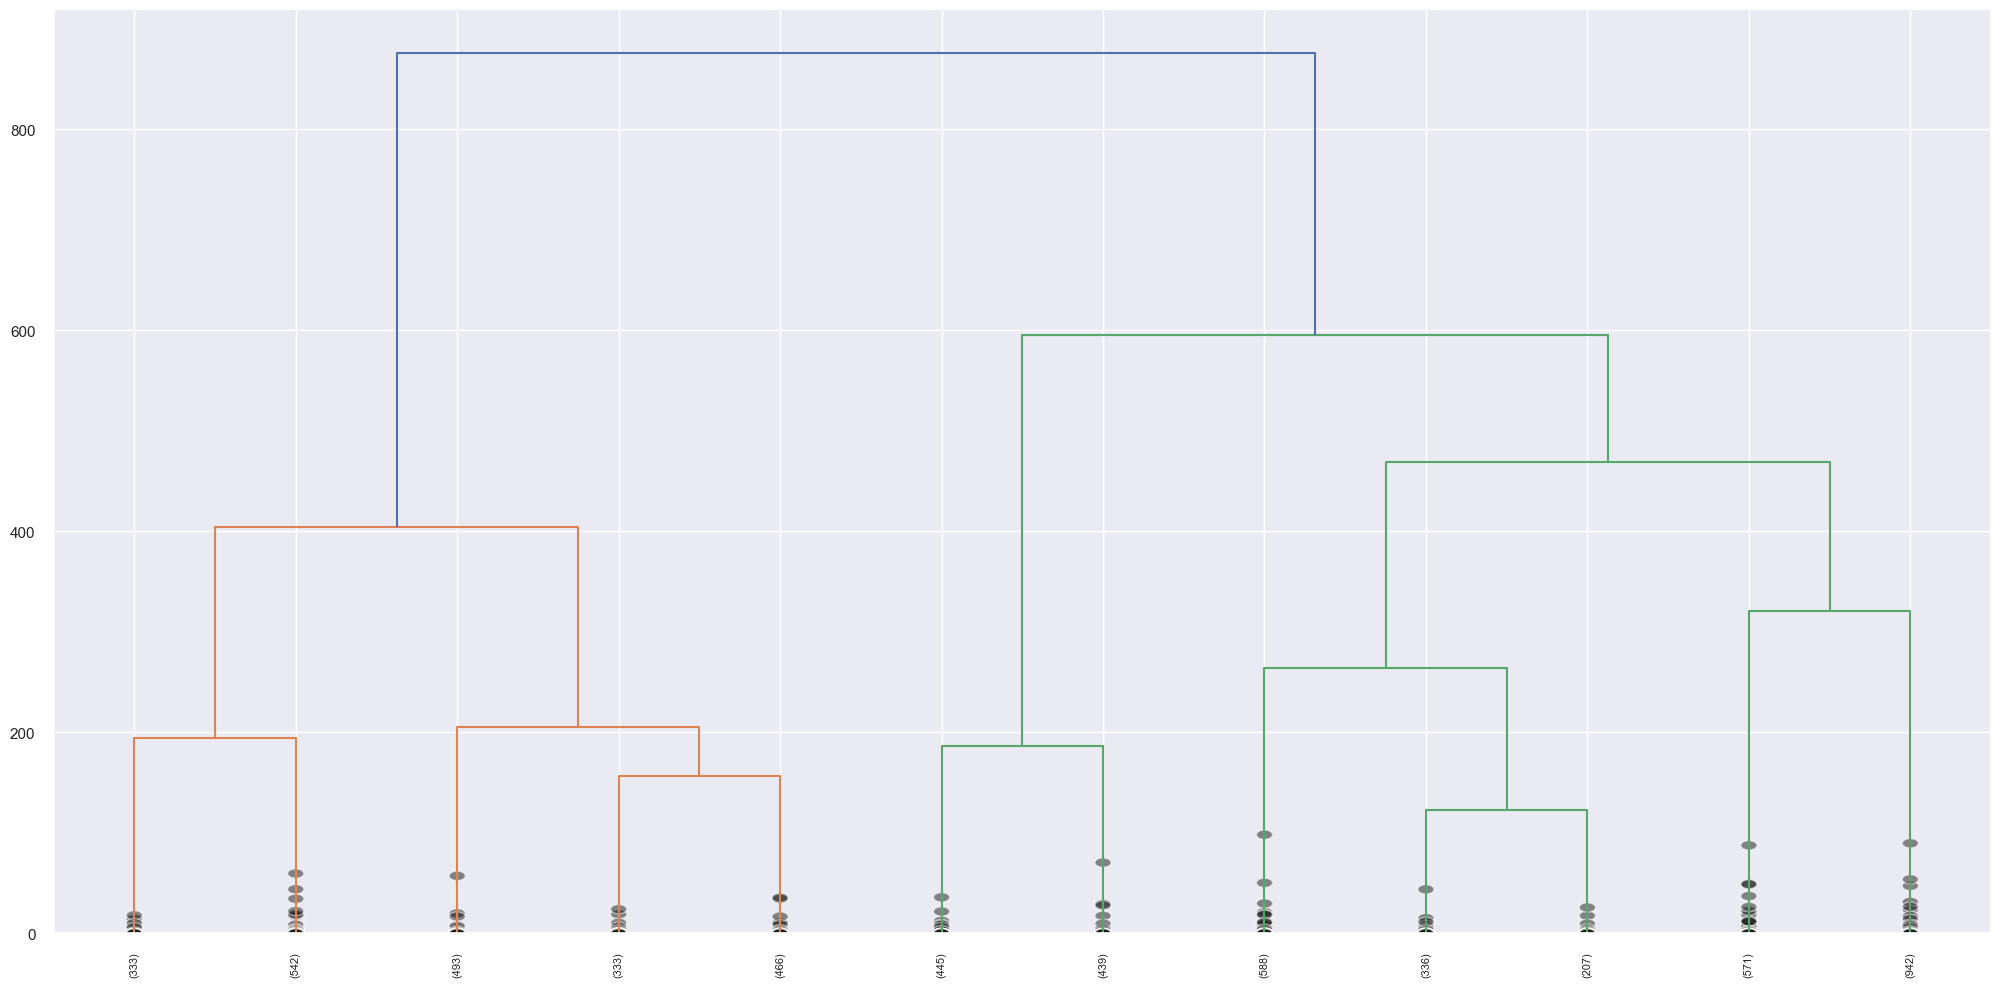

In [48]:
hc.dendrogram(
            hc_model,
            truncate_mode='lastp',
            p=12,
            leaf_rotation=90,
            leaf_font_size=8,
            show_contracted=True
)
plt.show()

### 7.3.1 - Hierarchical Cluster Silhouette

In [49]:
hc_list = []
for k in cluster:
    # Model Definition and Training
    hc_model = hc.linkage( X, 'ward' )

    # Model Predict
    labels = hc.fcluster( hc_model, k, criterion='maxclust' )

    # metrics
    sil = mt.silhouette_score( X, labels, metric='euclidean' )
    hc_list.append( sil )

Text(0.5, 1.0, 'HC: Silhouette Score x K')

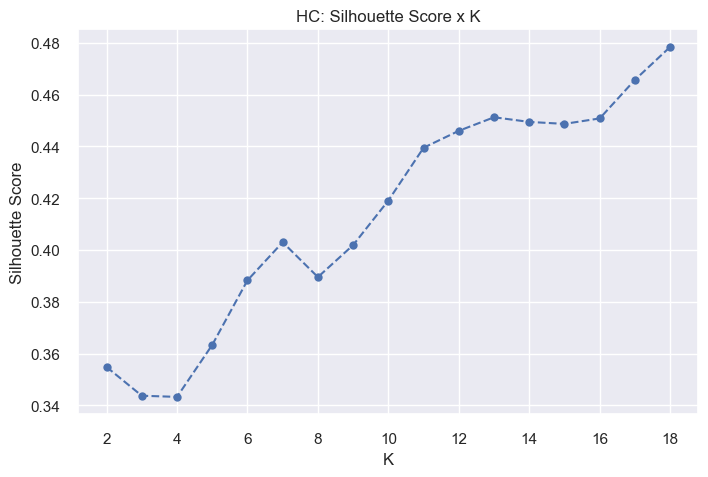

In [50]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, hc_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('HC: Silhouette Score x K')

## 7.4 - DBSCAN

In [ ]:
# eps=0.01
# min_samples=20

# # Model Definition
# dbscan_model = cc.DBSCAN( eps=eps, min_samples=min_samples )

# # Model Training and Predict
# labels = dbscan_model.fit_predict( X )

# db_sil = mt.silhouette_score( X, labels, metric='euclidean' )
# print( 'Silhouette Score: {}'.format( sil ) )
# print( 'Number of Cluster: {}'.format( len( unique( labels) ) ) )
# print( unique( labels ))

In [ ]:
# from sklearn.neighbors import NearestNeighbors

In [ ]:
# neighbors = NearestNeighbors( n_neighbors = min_samples).fit( X )
# distances, indexes = neighbors.kneighbors( X )

In [ ]:
# distances = np.sort( distances, axis=0 )
# distances = distances[:, 1]

In [ ]:
# plt.figure( figsize=(8, 5) )
# plt.plot( distances )

## 7.5 - Silhouette Analysis

In [ ]:
fig, ax = plt.subplots( 3, 2 )
fig.set_size_inches( 25, 20 )

for k in cluster:
    q, mod = divmod( k, 2 )
    
    ax[q-1, mod].set_xlim( [-0.1, 1] )
    ax[q-1, mod].set_ylim( [0, len( X ) + ( k+1 )*10] )
    
    # Model Definition and Training
    hc_model = hc.linkage( X, 'ward')

    # Model Predict
    labels = hc.fcluster( hc_model, k, criterion='maxclust')
    
    # Performance
    ss = mt.silhouette_score( X, labels, metric='euclidean')
    print( ' For K = {}. Silhouette Score: {}'.format( k, ss ) )

    
    samples_silhouette_values = mt.silhouette_samples( X, labels )

    y_lower = 10
    for i in range( k ):
        # Select Clusters
        ith_samples = samples_silhouette_values[ labels == i ]

        # Size Clusters
        size_cluster_i = ith_samples.shape[0]
        
        # Sort values
        ith_samples.sort()    

        # Limits
        y_upper = y_lower + size_cluster_i

        ax[q-1, mod].fill_betweenx( np.arange( y_lower, y_upper ), 0, ith_samples )
        
        y_lower = y_upper + 10 
     
        cmap = cm.get_cmap( 'Spectral')
        color = cmap( i/k )
    
    
    
    
ax[q-1, mod].set_yticks([])
ax[q-1, mod].set_xticks([-0.1, 0.2, 0.4, 0.6, 0.8, 1])

## 7.6 - Results

In [ ]:
# Model Name / K=2 / K=3 / K=4 / K=5 / ...
# KMeans       SS    SS    SS    SS
# GMM          SS    SS    SS    SS
# HC           SS    SS    SS    SS
# DBSCAN       SS    SS    SS    SS

In [51]:
df_results = pd.DataFrame(
                          {'KMeans': kmeans_list,
                           'GMM': gmm_list,
                           'HC':hc_list}
).T

df_results.columns = cluster

In [52]:
df_results.style.highlight_max( color='lightgreen', axis=1 ) #identifying the highest value for each ml model

,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
KMeans,0.372272,0.389647,0.376582,0.378847,0.428436,0.436885,0.443382,0.439926,0.435539,0.461579,0.462122,0.467499,0.468627,0.480685,0.489076,0.501199,0.483624
GMM,0.308471,0.370731,0.358520,0.320680,0.412372,0.382896,0.342615,0.398650,0.363914,0.440968,0.414453,0.375558,0.379401,0.446452,0.360067,0.452859,0.459630
HC,0.354804,0.343701,0.343252,0.363321,0.388256,0.402973,0.389511,0.401875,0.419080,0.439460,0.445991,0.451229,0.449430,0.448673,0.450782,0.465683,0.478404


# 8 - MACHINE LEARNING TRAINING

## 8.1 - K-Means

In [73]:
# Model Definition
k = 11
kmeans = cc.KMeans( init='random', n_clusters=k, n_init=300, random_state=42 )

# Model Trainin
kmeans.fit( X )

# Model Prediction
labels = kmeans.labels_

## 8.2 - GMM

In [57]:
# k = 11
# # Model Definition
# gmm_model = mx.GaussianMixture( n_components=k, n_init=300, random_state=42  )
    
# # Model Training
# gmm_model.fit( X )

# # Model Predict
# labels = gmm_model.predict( X )

## 8.3 - HC

In [66]:
# k=14
# # Model Definition and Training
# hc_model = hc.linkage( X, 'ward' )

# # Model Predict
# labels = hc.fcluster( hc_model, k, criterion='maxclust' )

## 8.2 - Cluster Validation

In [74]:
# WSS
print('WSS value: {}'. format( kmeans.inertia_) )

# Silhouette Score
print( 'SS Score: {}'.format( mt.silhouette_score( X, labels, metric='euclidean' ) ) )

WSS value: 82754.640625
SS Score: 0.4685884714126587


# 9 - CLUSTER ANALYSIS

In [75]:
df9 = X.copy()
df9['cluster'] = labels

## 9.1 - Vizualization Inspection


<AxesSubplot:xlabel='embedding_x', ylabel='embedding_y'>

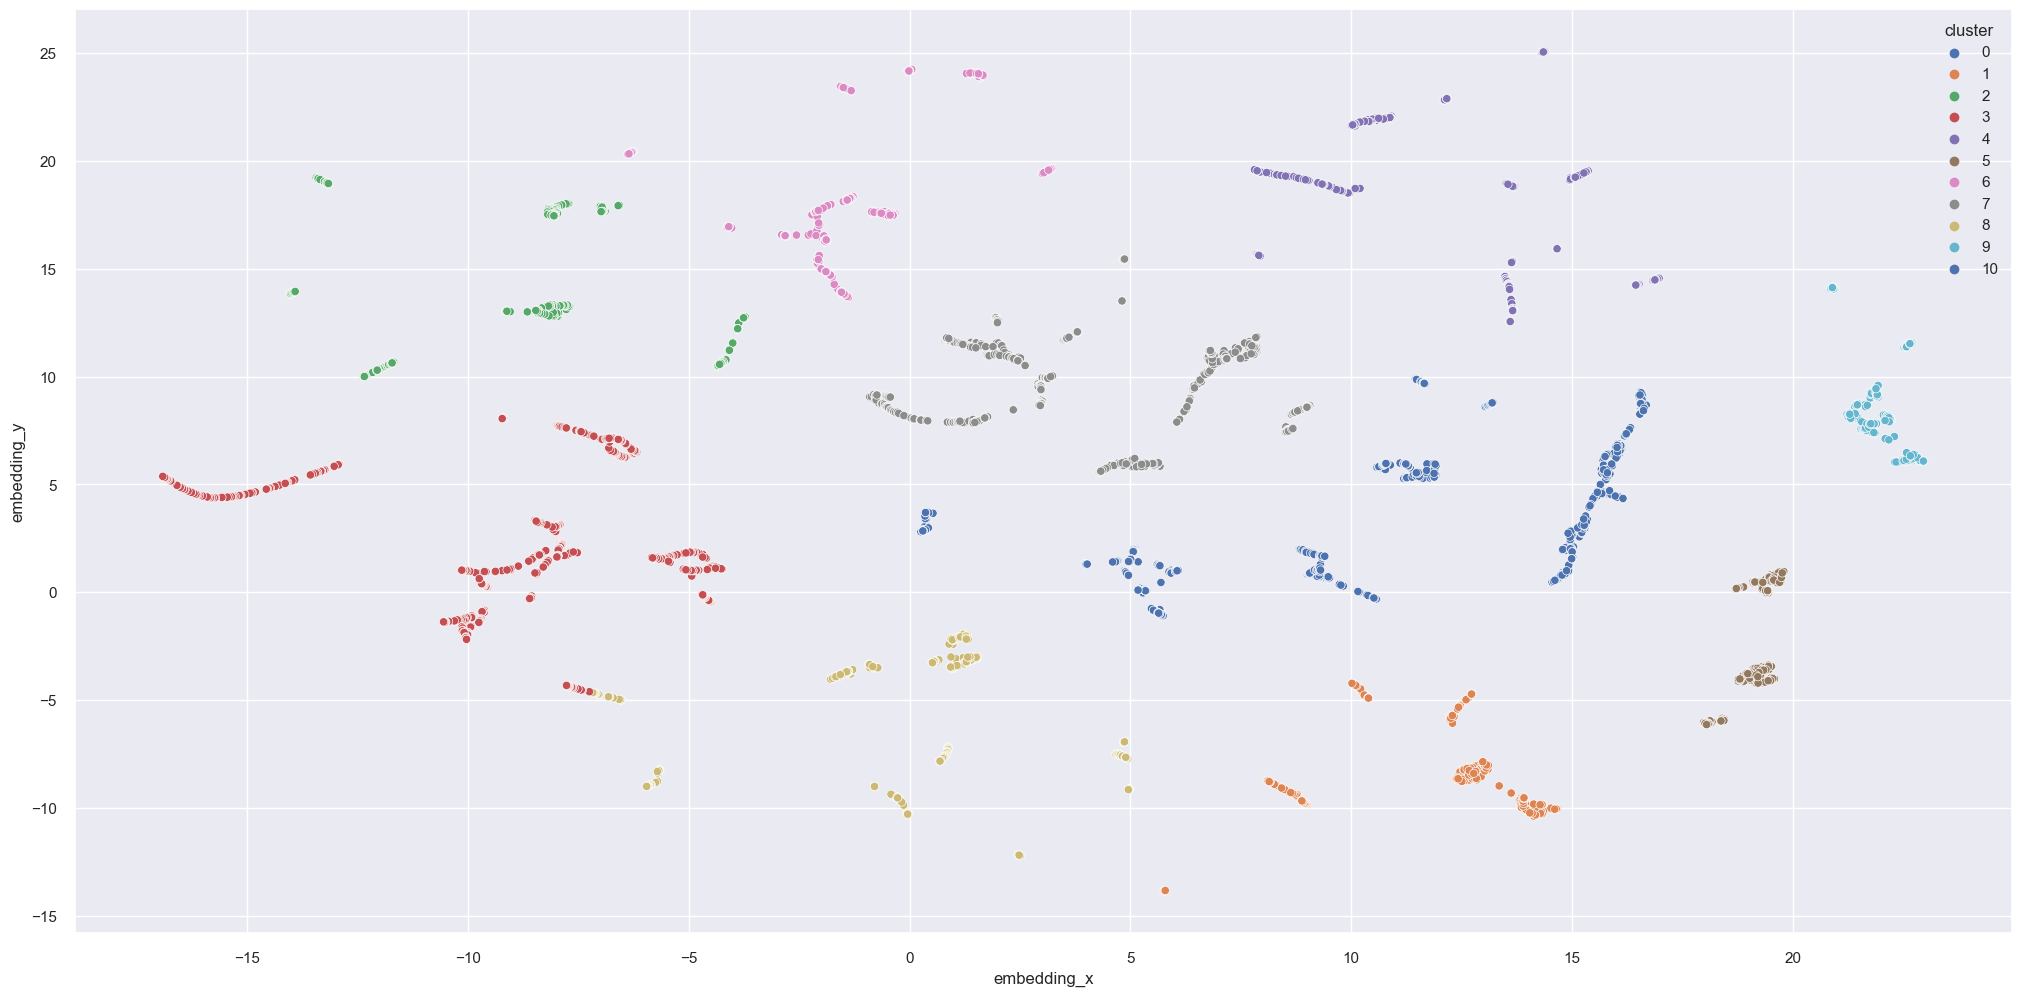

In [76]:
sns.scatterplot( x='embedding_x', y='embedding_y', hue='cluster', data=df9, palette='deep')

In [ ]:
# Silhouette 4 clusters
# visualizer = SilhouetteVisualizer( kmeans, colors='yellowbrick' )
# visualizer.fit( X )
# visualizer.finalize()

## 9.2 - 2D Plot

In [ ]:
# df_viz = df9.drop( columns='customer_id', axis=1)
# sns.pairplot( df_viz, hue='cluster')

## 9.3 - UMAP

Machine Learning - Manifold

Aprendizado por topologia: PCA - Metodo baseado em matriz ou espaco entre distancias. Temos 9 condicoes, cumprir 9 colorarios para ter uma garantia de espaco. Espaco de Hilbert, etc.AffinityPropagation

UMAP, T-SNE ( 2009 )- Abordagem por topologia ( Manifold ). Topologia sao grafos em alta dimensionalidade

In [ ]:
# # UMAP 
# reducer = umap.UMAP(n_neighbors=90, random_state=42)
# embedding = reducer.fit_transform( X )

# # Embedding 
# df_viz['embedding_x'] = embedding[:, 0]
# df_viz['embedding_y'] = embedding[:, 1]

# # Plot UMAP
# sns.scatterplot( 
#                  x='embedding_x',
#                  y='embedding_y', 
#                  hue='cluster',
#                  palette=sns.color_palette('hls',
#                                            n_colors=len(df_viz['cluster'].unique())),
#                  data=df_viz)
                                           


## 9.4 - Cluster Profile

In [77]:
df94 = df4[ cols_selected ].copy()
df94['cluster'] = labels
df94.head()

,customer_id,gross_revenue,recency_days,qty_of_products,frequency,qty_returns,cluster
0,17850,5391.21,372.0,1733.0,17.000000,40.0,1
1,13047,3232.59,56.0,1390.0,0.028302,35.0,1
2,12583,6705.38,2.0,5028.0,0.040323,50.0,0
3,13748,948.25,95.0,439.0,0.017921,0.0,8
4,15100,876.00,333.0,80.0,0.073171,22.0,6


In [78]:
# Number of Customer
df_cluster = df94[['customer_id', 'cluster']].groupby('cluster').count().reset_index()
df_cluster['perc_customer'] = 100*( df_cluster['customer_id'] / df_cluster['customer_id'].sum() )

# Avg Gross Revenue
df_avg_gross_revenue = df94[['gross_revenue', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_gross_revenue, how='inner', on='cluster')

# Avg Recency Days
df_avg_recency_days = df94[['recency_days', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_recency_days, how='inner', on='cluster')

# Avg Qty Products
df_qty_product = df94[['qty_of_products', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_qty_product, how='inner', on='cluster')

# Avg Frequency
df_freq = df94[['frequency', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_freq, how='inner', on='cluster')

# Avg Returns
df_ret = df94[['qty_returns', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_ret, how='inner', on='cluster')
df_cluster

,cluster,customer_id,perc_customer,gross_revenue,recency_days,qty_of_products,frequency,qty_returns
0,0,650,11.413521,4646.971846,67.363077,2738.456923,0.304586,42.756923
1,1,455,7.989464,2728.460132,59.951648,1511.942857,0.245011,18.410989
2,2,433,7.603161,277.815289,195.937644,91.764434,0.785038,1.771363
3,3,730,12.818262,81.811397,188.832877,22.068493,0.974978,0.542466
4,4,495,8.691835,6171.693313,131.573737,3439.917172,0.747630,247.872727
5,5,309,5.425812,1797.191262,43.854369,1054.271845,0.029683,17.967638
6,6,473,8.305531,516.236702,98.847780,242.084567,0.343540,3.443975
7,7,897,15.750658,441.103701,131.903010,207.370123,0.717112,2.537347
8,8,502,8.814750,1307.688705,116.942231,527.336653,0.558106,7.517928
9,9,333,5.847234,1350.814384,52.396396,758.201201,0.035936,11.426426


In [ ]:
# 9 Insiders
- No. customers: 495 customers (8.7%)
- Recency: 131 days
- Qty Products: 3440
- Avg Revenue: $6171,70
# 8 Cluster_A
# 2 Cluster_B
# 3 Cluster_C 
# 1 Cluster_D
# 4 Cluster_E
# 6 Cluster_F
# 5 Cluster_G
# 7 Cluster_H

# 10 - EXPLORATORY DATA ANALYSIS

## 10.1 - Mind Map of Hypothesis

1. Phenomen
2. Entity
3. caracteristics of Entity

In [ ]:
# URL da imagem
url_imagem = '../reports/figures/mindmap.png'  # Substitua pela URL da sua imagem

# Exibe a imagem no notebook
display(Image(url=url_imagem))

## 10.2 - Business Hypothesis

In [ ]:
Cluster | Comparation Basys | Variable to test

## 10.3 - Hypothesis Priority

# Purchases

1. Customers in the insider cluster make their payments using credit card in 80% of their purchases.
2. **Customers in the insider cluster has an avg ticket 10% higher than the cluster A.**
3. **Customers in the insider cluster has a basket size containing more than 5 items.**
4. **Customers in the insider cluster has a purchase volume higher than 10% of the total.**
5. **Customers in the insider clsuter has less returns than the average of the database.**

In [ ]:
# Customers
1. 60% of the customers in the insiders cluster are single. 
2. 10% of the customers in the insiders cluster are from 24 to 35 years old.
3. 40% of delivery locations are within a 50km radius.
4. 5% of the customers in the insiders cluster receive more than 100.000 dolars annualy.
5. 90% of the customers in the insiders cluster hold a BSc.

In [ ]:
# Products
1. 30% of all products are large
2. The median prices of products purchased by customers in the insider cluster are 10% higher than the median prices of all products.
3. The percentile prices of the products bought from the insider cluster.
4. The average weight of the products bought from customers in the insider cluster is higher than the average weight of the products bought from customers in the other clusters.
5. The average age of products purchased by customers in the insider cluster is less than 15 days.

In [ ]:
# Business Question
1. Who are the eligible individuals to participate in the program?
    - Revenue:
        - High average ticket value
        - High customer lifetime value (LTV)
        - Low recency
        - Low churn probability
        - High LTV prediction
        - High purchase propensity
        - Cost:

        - Low return rate
        - Purchase Experience:

        - High average ratings  

2. How many customers will be part of the group?
        - Total number of customers
        - % of the insiders group
    
3.  What are the main characteristics of these customers?
    - Customer characteristics:
        - Age
        - Location
       
    - Consumption characteristics:
        - Attributes of clustering

4. What percentage of the revenue comes from the selected group?
    - Total annual revenue
    - Revenue from the Insiders group

5. What is the revenue expectation for this group in the upcoming months?
    - LTV (Customer Lifetime Value) of the Insiders group
    - Cohort analysis
    
6. What are the eligibility criteria for someone to join the group?
    - Define the frequency (1 month, 2 months, etc.).
    - The person needs to be similar to another person in the group.
    - What are the criteria for someone to be removed from the group?

7. Define the frequency (1 month, 2 months, etc.).
    - The person needs to be dissimilar to another person in the group.
    - How can we ensure that the group performs better than the rest of the customer base?

8. A/B testing.
    - Bayesian A/B testing.
    - Hypothesis testing.
    - What actions can the marketing team take to increase revenue?

9. Discounts.
    - Purchase preferences.
    - Company visits.

## 10.4 - Hypothesis Validation

In [80]:
df10 = df94.copy()
df10.head()

,customer_id,gross_revenue,recency_days,qty_of_products,frequency,qty_returns,cluster
0,17850,5391.21,372.0,1733.0,17.000000,40.0,1
1,13047,3232.59,56.0,1390.0,0.028302,35.0,1
2,12583,6705.38,2.0,5028.0,0.040323,50.0,0
3,13748,948.25,95.0,439.0,0.017921,0.0,8
4,15100,876.00,333.0,80.0,0.073171,22.0,6


In [ ]:
# Purchases

1. Customers in the insider cluster make their payments using credit card in 80% of their purchases.
2. Customers in the insider cluster has an avg ticket 10% higher than the cluster A.
3. **Customers in the insider cluster has a basket size containing more than 5 items.**
4. **Customers in the insider cluster have a purchase volume (product) higher than 10% of the total.**
5. **Customers in the insider cluster has a purchase  volume (revenue) higher than 10% of the total.**
6. **Customers in the insider clsuter has less returns than the average of the database.**

# Customers
1. 60% of the customers in the insiders cluster are single. 
2. 10% of the customers in the insiders cluster are from 24 to 35 years old.
3. 40% of delivery locations are within a 50km radius.
4. 5% of the customers in the insiders cluster receive more than 100.000 dolars annualy.
5. 90% of the customers in the insiders cluster hold a BSc.

# Products
1. 30% of all products are large
2. The median prices of products purchased by customers in the insider cluster are 10% higher than the median prices of all products.
3. The percentile prices of the products bought from the insider cluster.
4. The average weight of the products bought from customers in the insider cluster is higher than the average weight of the products bought from customers in the other clusters.
5. The average age of products purchased by customers in the insider cluster is less than 15 days.


### 4. **Customers in the insider cluster have a purchase volume (product) higher than 10% of the total.** 
**Hiphotesis is True.** The Insider Cluster has a volume of purchases around 57%

In [82]:
df_sales_insider = df10.loc[df10['cluster'] == 4, 'qty_of_products'].sum()
df_sales_total = df10.loc[:,'qty_of_products'].sum()

print('% Sales Insiders: {:.2f}%'.format( 100*df_sales_insider / df_sales_total ) )

% Sales Insiders: 31.00%


### 5. **Customers in the insider cluster has a purchase  volume (revenue) higher than 10% of the total.**
**Hipothesis is True.** The Insider Cluster has a GMV volume of 55%.

In [83]:
df_gmv_insider = df10.loc[df10['cluster'] == 4, 'gross_revenue'].sum()
df_gmv_total = df10.loc[:,'gross_revenue'].sum()

print('% GMV Insiders: {:.2f}%'.format( 100*df_gmv_insider / df_gmv_total ) )

% GMV Insiders: 30.23%


### 6. **Customers in the insider clsuter has less returns than the average of the database.**
**Hipothesis is False.** The Insider Cluster has return avg higher than the general average.

In [84]:
df_avg_return_insider = df10.loc[df10['cluster'] == 4, 'qty_returns'].mean()
df_avg_return_all = df10.loc[:,'qty_returns'].mean()

print('Avg Return Insiders: {} vs Avg Return Al: {}'.format( np.round( df_avg_return_insider, 0),
                                                             np.round( df_avg_return_all, 0 ) ) )

Avg Return Insiders: 248.0 vs Avg Return Al: 31.0


### The median revenue of the customers in the insider cluster are 10% higher than the median prices of all.
**Hipothesis is True.** The revenue median of the customers in the insider cluster is around 500% higher.

In [85]:
df_median_gmv_insider = df10.loc[df10['cluster'] == 4, 'gross_revenue'].median()

df_median_gmv_total = df10.loc[:, 'gross_revenue'].median()

gmv_dif = ( df_median_gmv_insider - df_median_gmv_total )/ df_median_gmv_total

print('Median Diff: {:.2f}%'.format( 100 * gmv_dif ) )

Median Diff: 65.96%


### The percentile prices of the products bought from the insider cluster.


In [ ]:
np.percentile( df10.loc[df10['cluster'] == 4, 'gross_revenue'], q=0.1)

In [ ]:
np.percentile( df10.loc[df10['cluster'] == 4, 'gross_revenue'], q=0.9)

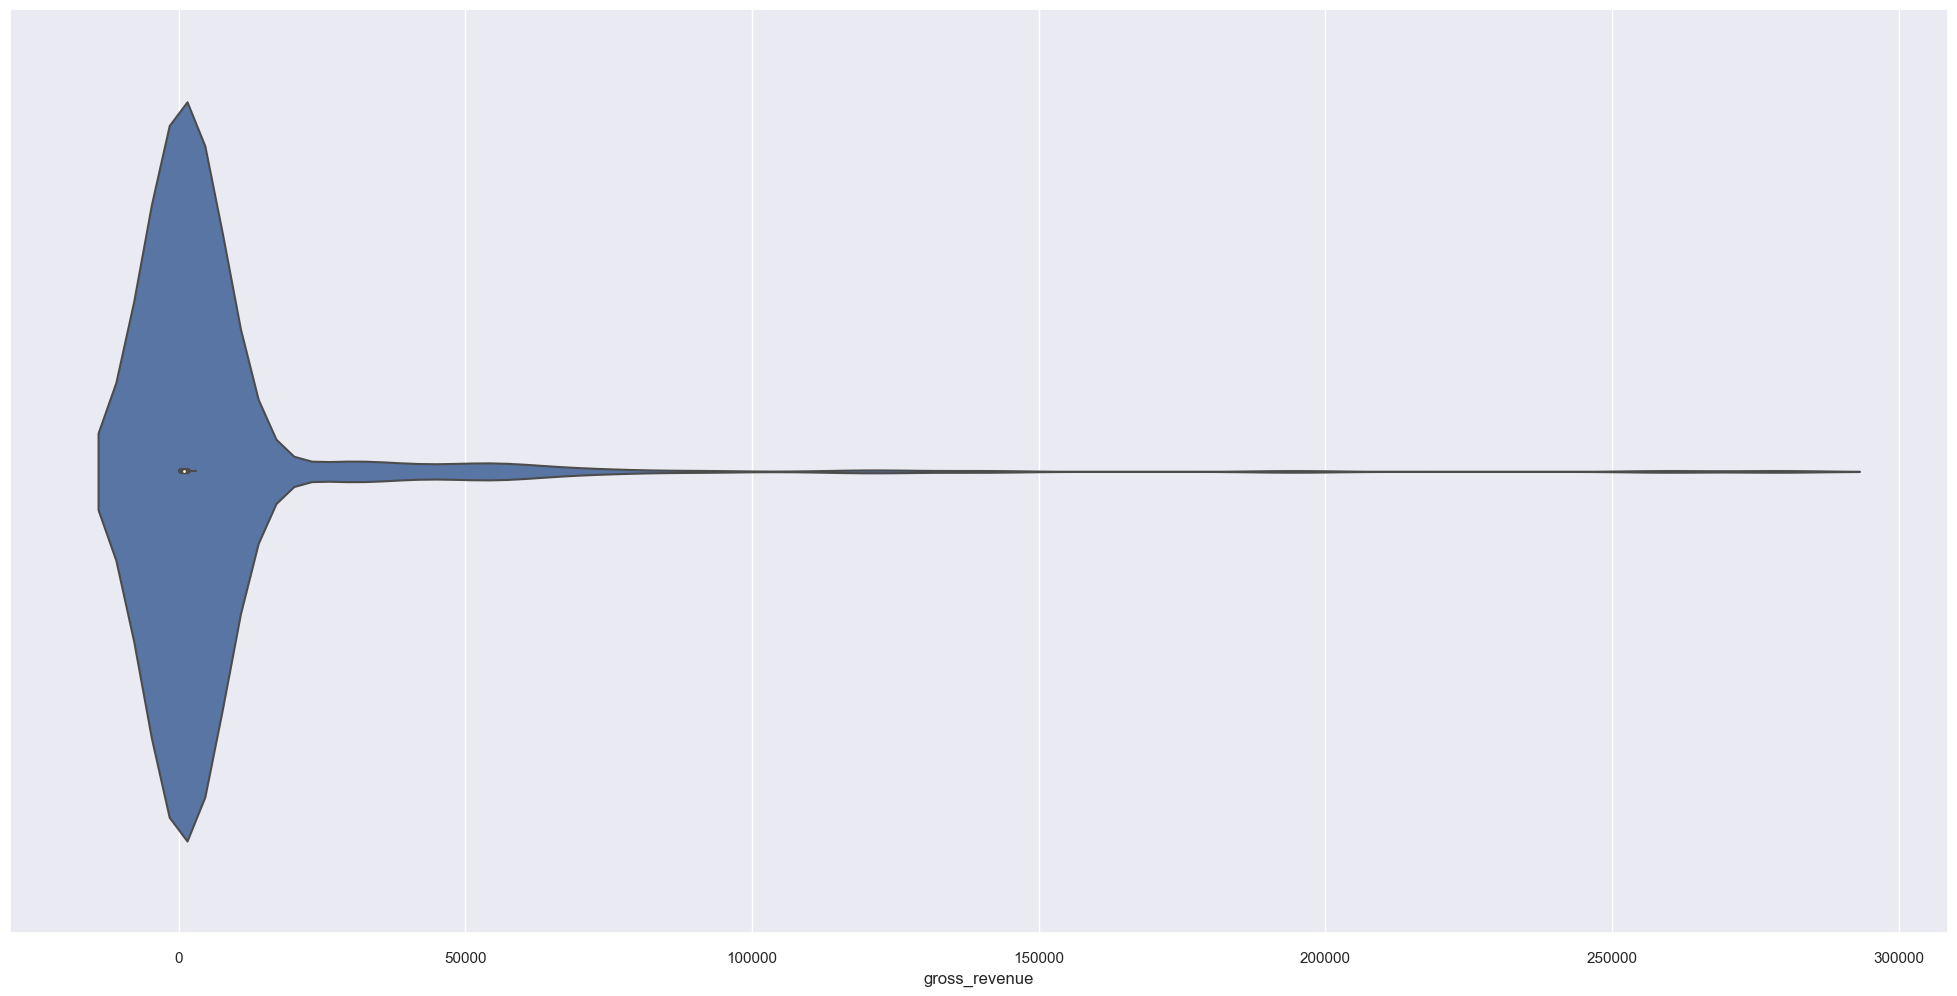

In [86]:
sns.violinplot( x = df10.loc[df10['cluster'] == 4, 'gross_revenue']);

In [ ]:
df_aux = df10.loc[(df10['cluster'] == 1) & (df10['gross_revenue'] < 10000), 'gross_revenue']
sns.violinplot( x = df_aux )

## 10.5 - Business Questions

In [ ]:
1. Whom are the customers elegible to join the insiders program?

In [87]:
df10.loc[df10['cluster'] == 4, 'customer_id'].head()

8     15311
12    16029
15    17511
19    13408
27    14045
Name: customer_id, dtype: int32

In [ ]:
2. How many customers will be part of the group?

In [88]:
df10.loc[df10['cluster'] == 4, 'customer_id'].size

495

In [ ]:
3. What are the main characteristics of these customers?

In [ ]:
- No. customers: 495 customers (8.7%)
- Recency: 131 days
- Qty. Products: 3440
- Avg Revenue: $6171,70

In [ ]:
4. What percentage of the revenue comes from the selected group?

In [ ]:
df_insiders_gmv = df10.loc[df10['cluster'] == 9, 'gross_revenue'].sum()
df_all_gmv = df10.loc[:, 'gross_revenue'].sum()

print( '% GMV from Insiders: {}'.format( df_insiders_gmv / df_all_gmv ))

In [ ]:
5. What is the revenue expectation for this group in the upcoming months?

In [ ]:
6. What are the conditions for someone to be eligible for the group?

In [ ]:
7. What are the conditions for someone to be removed from the group?

In [ ]:
8. How do we know that the group is better than the rest of the base?

In [ ]:
9. What actions can the marketing team take to increase revenue?

# 11 - DEPLOY